# Task 4.3: Machine Learning Model Development for Move Tickers (Group)

## Group Information

Please enter your group details below:

**Group Name:**  Group 17  



This notebook guides you through Task 4.3, where you will design, implement, and validate machine learning models using financial time series data for Move Tickers.

You are encouraged to explore one or more of the following directions, depending on your project’s business problem: forecasting, classification, clustering, anomaly detection, or a hybrid approach.

📌 **Note:** This task is directly connected to your previously completed proposal and your database from Task 1.2.
---

## ⚠️ Important Note:


Do not change the order of the steps in this template. However, feel free to **add extra cells** where necessary to split each step into smaller parts or to provide additional explanations. For example, you may add cells to explain your reasoning behind decisions, show intermediate results, or clarify what you considered at each stage of the process.


## 🔍  Step 1: Review Your Problem Statement

Briefly revisit and summarise the problem statement from your group proposal.
This will help keep your objectives focused and aligned throughout the modelling task.

👉 Include your business question or challenge and explain its relevance to Move Tickers.

During earnings season, investors are often overwhelmed by the massive volume of financial data released in a short period. Earnings reports are complex, time-consuming to interpret, and EPS (Earnings Per Share) surprises are frequently misunderstood or misused. This can lead to missed opportunities or poor investment decisions.

This challenge is highly relevant to Move Tickers, as the platform aims to highlight stocks with significant post-earnings price movements. By addressing this problem, we can develop models and visual tools that simplify financial data, clarify EPS impacts, and assist users in spotting meaningful stock "moves" faster and more accurately—supporting smarter and timelier investment decisions.

##  🗄️ Step 2: Load and Explore Data

You should load the data that you have stored in the SQL database table you created during **Task 1.2: Database Creation**. We have included a template of how to do this below with SQLAlchemy, make sure to fill in the missing parts.

Importing libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans 

Importing Data 

In [ ]:
import pandas as pd

path = './stock_metrics.csv'
df = pd.read_csv(path)

In [13]:
import pandas as pd
from sqlalchemy import create_engine

# Replace with your actual database connection details
db_params = {
    'host': '194.171.191.226',
    'port': '3432',
    'database': 'group_17_warehouse',
    'user': 'group_17_user',
    'password': 'group_17_blockd25'
}

db_url = f"postgresql://{db_params['user']}:{db_params['password']}@{db_params['host']}:{db_params['port']}/{db_params['database']}"

engine = create_engine(db_url, echo=True)
df_alch = pd.read_sql_query("SELECT * FROM stock_metrics", engine)

2025-06-17 10:20:57,301 INFO sqlalchemy.engine.Engine select pg_catalog.version()
2025-06-17 10:20:57,302 INFO sqlalchemy.engine.Engine [raw sql] {}
2025-06-17 10:20:57,310 INFO sqlalchemy.engine.Engine select current_schema()
2025-06-17 10:20:57,311 INFO sqlalchemy.engine.Engine [raw sql] {}
2025-06-17 10:20:57,317 INFO sqlalchemy.engine.Engine show standard_conforming_strings
2025-06-17 10:20:57,318 INFO sqlalchemy.engine.Engine [raw sql] {}
2025-06-17 10:20:57,324 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2025-06-17 10:20:57,326 INFO sqlalchemy.engine.Engine SELECT * FROM stock_metrics
2025-06-17 10:20:57,327 INFO sqlalchemy.engine.Engine [raw sql] {}
2025-06-17 10:20:57,627 INFO sqlalchemy.engine.Engine ROLLBACK


In [1]:
import pandas as pd
df_alch = pd.read_csv('stock_metrics.csv')

In [ ]:
# Save the DataFrame to a CSV file on your device
df_alch.to_csv("stock_metrics_downloaded.csv", index=False)

#### 📌 **Note:** You must run the above cell at least once to retrieve the data from your database. After running it once, you can save the data locally, which will prevent the need to reconnect to the server when working remotely, especially if you encounter access issues to the server.

## 📊 Step 3: Preprocessing

Clean and prepare your data for machine learning. This may involve:
- Handling missing values and outliers
- Feature engineering (e.g., lag variables, moving averages)
- Normalisation or scaling
- Encoding categorical variables (if applicable)

### Pre-Processing for regression


In [ ]:
import pandas as pd

# Load dataset from CSV file
df = pd.read_csv('./stock_metrics.csv')

# List of companies to process
companies = ['AAPL', 'GOOG', 'QCOM']

# Columns that may cause data leakage and should be excluded
leaky_cols = ['eps_estimate', 'eps_actual', 'eps_surprise', 'surprise_percent']

preprocessed_data = []

for company in companies:
    # Filter data for the current company
    df_company = df[df['ticker'] == company].copy()
    
    if len(df_company) == 0:
        print(f" No data for {company}, skipping.")
        continue

    # Fill missing values with zero (simple imputation)
    df_company.fillna(0, inplace=True)

    X = df_company.drop(columns=["target", "date", "timestamp", "ticker"] + leaky_cols)
    y = df_company["target"]

    preprocessed_data.append({
        "company": company,
        "X": X,
        "y": y.reset_index(drop=True)
    })


### Splitting data for regression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split and scale the data for each company
for data in preprocessed_data:
    X = data["X"]
    y = data["y"]

    # Split into train and test sets without shuffling to keep time order
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Save scaled and split data back
    data["X_train"] = X_train_scaled
    data["X_test"] = X_test_scaled
    data["y_train"] = y_train.reset_index(drop=True)
    data["y_test"] = y_test.reset_index(drop=True)

### Pre-processing for classification

#### Filling missing values, setting index, organizing data, creating new target feature

In [2]:
# Filling missing values with 0. This is important for the "EPS" values which are only available for years 2024-2025 but very important. 
# To ensure preserve all other rows from earlier years, we replace nulls with 0 as it does not impact the model as much
df_alch.fillna(value=0, inplace=True)

# Setting the date column as index to ensure order of time
df_alch['date'] = pd.to_datetime(df_alch['date'])
df_alch.set_index('date', inplace=True)

#Making three separate datasets for each company of interest
aapl_data = df_alch[df_alch['ticker'] == 'AAPL']
qualcomm_data = df_alch[df_alch['ticker'] == 'QCOM']
googl_data = df_alch[df_alch['ticker'] == 'GOOG']

#Creating direction feature for each of the datasets which indicates whether the price of stock next day goes up (1) or down(0)
aapl_data['direction'] = (aapl_data['target'].shift(-1) > aapl_data['target']).astype(int)
qualcomm_data['direction'] = (qualcomm_data['target'].shift(-1) > qualcomm_data['target']).astype(int)
googl_data['direction'] = (googl_data['target'].shift(-1) > googl_data['target']).astype(int)

C:\Users\filip\AppData\Local\Temp\ipykernel_31440\4034705071.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  aapl_data['direction'] = (aapl_data['target'].shift(-1) > aapl_data['target']).astype(int)
C:\Users\filip\AppData\Local\Temp\ipykernel_31440\4034705071.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  qualcomm_data['direction'] = (qualcomm_data['target'].shift(-1) > qualcomm_data['target']).astype(int)
C:\Users\filip\AppData\Local\Temp\ipykernel_31440\4034705071.py:17: SettingWithCopyWarning

#### Splitting data and scaling the data

In [3]:
# Import required packages
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import MinMaxScaler

#Create training sets, test sets and labels
X_aapl = aapl_data.drop(columns=['target', 'ticker', 'timestamp', 'direction'])
y_aapl = aapl_data['direction']
X_train_aapl, X_test_aapl, y_train_aapl, y_test_aapl = train_test_split(X_aapl, y_aapl, test_size=0.2, shuffle=False)

X_qualcomm = qualcomm_data.drop(columns= ['target','ticker', 'timestamp', 'direction'])
y_qualcomm = qualcomm_data['direction']
X_train_qualcomm, X_test_qualcomm, y_train_qualcomm, y_test_qualcomm = train_test_split(X_qualcomm, y_qualcomm, test_size=0.2, shuffle=False)

X_googl = googl_data.drop(columns= ['target','ticker', 'timestamp', 'direction'])
y_googl = googl_data['direction']
X_train_googl, X_test_googl, y_train_googl, y_test_googl = train_test_split(X_googl, y_googl, test_size=0.2, shuffle=False)

# Scale features
scaler_qualcomm = MinMaxScaler()
X_train_qualcomm_scaled = scaler_qualcomm.fit_transform(X_train_qualcomm)
X_test_qualcomm_scaled = scaler_qualcomm.transform(X_test_qualcomm)

scaler_aapl = MinMaxScaler()
X_train_aapl_scaled = scaler_aapl.fit_transform(X_train_aapl)
X_test_aapl_scaled = scaler_aapl.transform(X_test_aapl)

scaler_googl = MinMaxScaler()
X_train_googl_scaled = scaler_googl.fit_transform(X_train_googl)
X_test_googl_scaled = scaler_googl.transform(X_test_googl)

## 🤖 Step 4. Model Development

### Regression model traning 

In this step, we train a Linear Regression model to learn the relationship between the selected features and the target variable. This serves as our baseline model for regression tasks. Model evaluation and comparison will be done in the following steps

### Linear Regression

Model Training for Companies

In [6]:
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

for data in preprocessed_data:
    company = data["company"]
    X_train = data["X_train"]
    y_train = data["y_train"]

    print(f"\nTraining models for {company}...")

    # Initialize and train Linear Regression model on training data
    lr = LinearRegression()
    lr.fit(X_train, y_train)

    # Initialize and train XGBoost Regressor on training data
    xgb = XGBRegressor(objective="reg:squarederror", n_estimators=100, random_state=42)
    xgb.fit(X_train, y_train)

    print(f"Training completed for {company}")



Training models for AAPL...
Training completed for AAPL

Training models for GOOG...
Training completed for GOOG

Training models for QCOM...
Training completed for QCOM


Traning AAPL

In [ ]:
company = "AAPL"
data = next(item for item in preprocessed_data if item["company"] == company)

# Select training features and targets from the preprocessed data
X_train = data["X_train"]
y_train = data["y_train"]

print(f"\nTraining Linear Regression model for {company}...")

# Initialize the Linear Regression model
lr = LinearRegression()

# Fit the model to the training data
lr.fit(X_train, y_train)

# Predict the target values for the training set
y_pred_train = lr.predict(X_train)


Training Linear Regression model for AAPL...


Traning QCOM

In [ ]:
company = "QCOM"
data = next(item for item in preprocessed_data if item["company"] == company)

# Select training features and targets from the preprocessed data
X_train = data["X_train"]
y_train = data["y_train"]

print(f"\nTraining Linear Regression model for {company}...")

# Initialize the Linear Regression model
lr = LinearRegression()

# Fit the model to the training data
lr.fit(X_train, y_train)

# Predict the target values for the training set
y_pred_train = lr.predict(X_train)



Training Linear Regression model for QCOM...


Traning GOOG

In [ ]:
company = "GOOG"
data = next(item for item in preprocessed_data if item["company"] == company)

# Select training features and targets from the preprocessed data
X_train = data["X_train"]
y_train = data["y_train"]

print(f"\nTraining Linear Regression model for {company}...")

# Initialize the Linear Regression model
lr = LinearRegression()

# Fit the model to the training data 
lr.fit(X_train, y_train)

# Predict the target values for the training set
y_pred_train = lr.predict(X_train)



Training Linear Regression model for GOOG...


### Classification model training

For classification we will assess the baseline accuracy of three models:

**Logistic Regression**

**Random Forest**

**XGBoost**

#### Logistic Regression

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
lr = LogisticRegression(random_state=42)
lr.fit(X_train_aapl_scaled, y_train_aapl)

LogisticRegression(random_state=42)

In [5]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_aapl_scaled, y_train_aapl)

RandomForestClassifier(random_state=42)

In [6]:
import xgboost 
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state = 42)
xgb.fit(X_train_aapl_scaled, y_train_aapl)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

### Baseline Dummy model

In [7]:
from sklearn.dummy import DummyClassifier
baseline = DummyClassifier(strategy='uniform', random_state=42) 
baseline.fit(X_train_aapl_scaled, y_train_aapl)

DummyClassifier(random_state=42, strategy='uniform')

## 📈 Step 5: Model Evaluation

Evaluate your models using suitable metrics for your problem, such as:
- Accuracy, Precision, Recall, F1-score (for classification)
- RMSE, MAE, R-squared (for regression)
- Silhouette Score, Davies-Bouldin Index (for clustering)

Ensure proper validation techniques such as cross-validation or backtesting.


📌  In addition to evaluating the performance of your developed model, compute a baseline performance metric (e.g., using a naive forecast, mean predictor, or a simple model). This baseline will serve as a reference point to help you assess how well your model performs compared to a simple alternative.


### Model Training for Multiple Companies


Training models for AAPL...
R² score of Linear Regression for AAPL: 0.9592
R² score of XGBoost Regression for AAPL: -0.7879


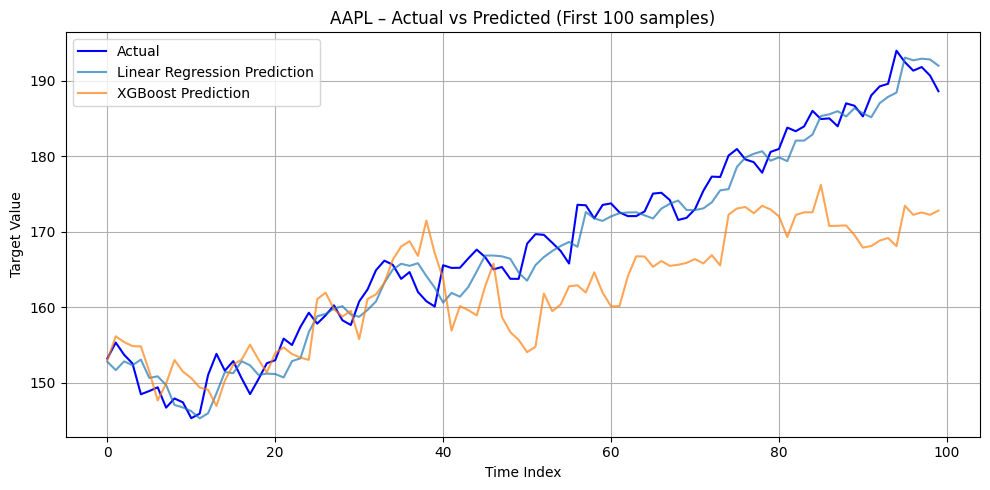


Training models for GOOG...
R² score of Linear Regression for GOOG: 0.9741
R² score of XGBoost Regression for GOOG: 0.8740


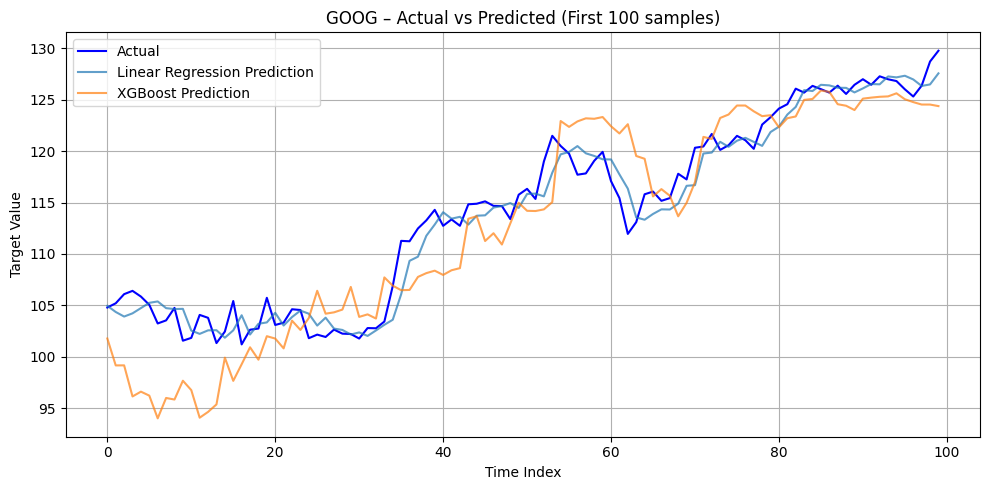


Training models for QCOM...
R² score of Linear Regression for QCOM: 0.8775
R² score of XGBoost Regression for QCOM: 0.7613


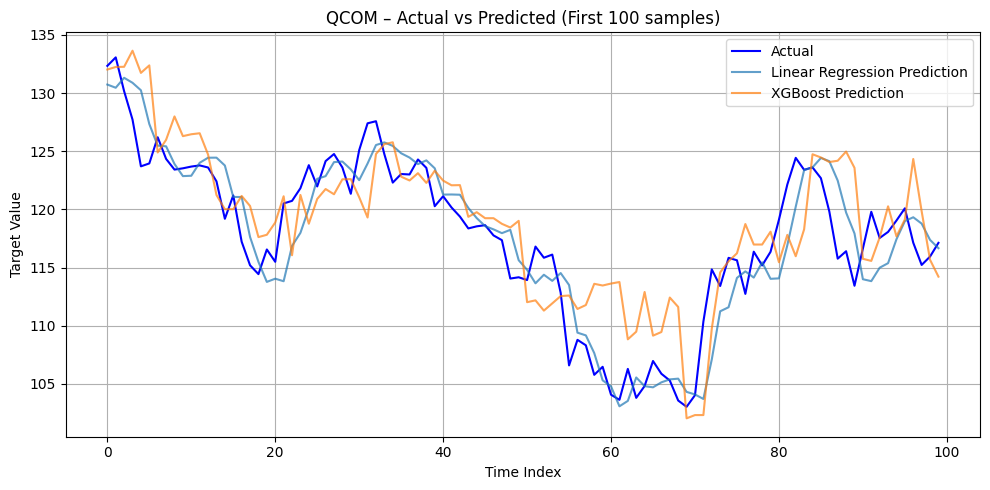

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

for data in preprocessed_data:
    company = data["company"]
    X_train, X_test = data["X_train"], data["X_test"]
    y_train, y_test = data["y_train"], data["y_test"]

    print(f"\nTraining models for {company}...")

    # Linear Regression model training and prediction
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    y_pred_lr = lr.predict(X_test)
    r2_lr = r2_score(y_test, y_pred_lr)

    # XGBoost Regression model training and prediction
    xgb = XGBRegressor(objective="reg:squarederror", n_estimators=100, random_state=42)
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)
    r2_xgb = r2_score(y_test, y_pred_xgb)

    print(f"R² score of Linear Regression for {company}: {r2_lr:.4f}")
    print(f"R² score of XGBoost Regression for {company}: {r2_xgb:.4f}")

    # Plot actual vs predicted for first 100 samples
    plt.figure(figsize=(10, 5))
    plt.plot(y_test.values[:100], label="Actual", color="blue")
    plt.plot(y_pred_lr[:100], label="Linear Regression Prediction", alpha=0.7)
    plt.plot(y_pred_xgb[:100], label="XGBoost Prediction", alpha=0.7)
    plt.title(f"{company} – Actual vs Predicted (First 100 samples)")
    plt.xlabel("Time Index")
    plt.ylabel("Target Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Linear Regression for AAPL


Training Linear Regression for AAPL...
R² score for Linear Regression (AAPL): 0.9592


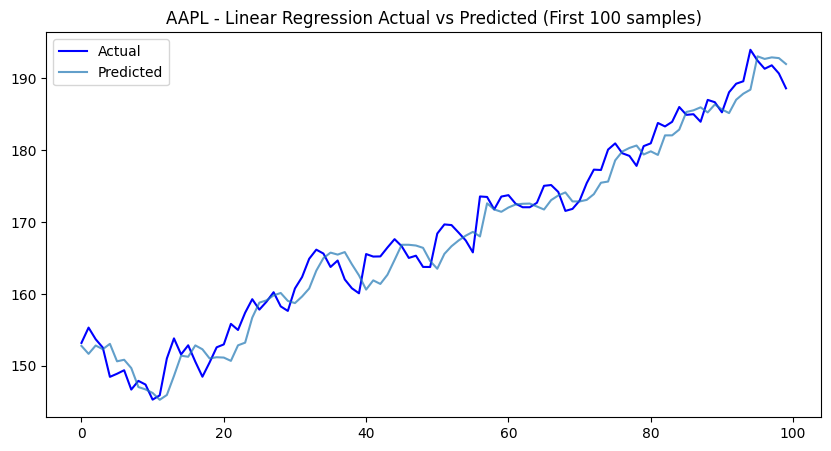

In [24]:
company = "AAPL"
data = next(item for item in preprocessed_data if item["company"] == company)

X_train, X_test = data["X_train"], data["X_test"]
y_train, y_test = data["y_train"], data["y_test"]

print(f"\nTraining Linear Regression for {company}...")

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"R² score for Linear Regression ({company}): {r2_lr:.4f}")

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label="Actual", color="blue")
plt.plot(y_pred_lr[:100], label="Predicted", alpha=0.7)
plt.title(f"{company} - Linear Regression Actual vs Predicted (First 100 samples)")
plt.legend()
plt.show()

XGBoost Regression for AAPL


Training XGBoost for AAPL...
R² score for XGBoost (AAPL): -0.7879


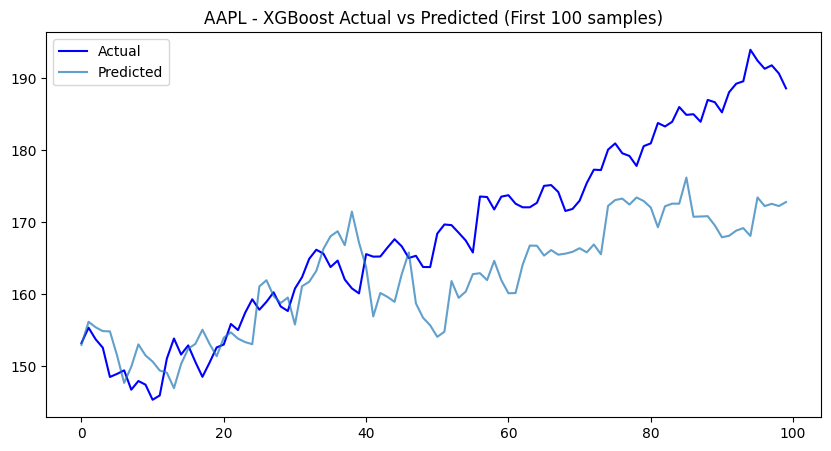

In [25]:
from xgboost import XGBRegressor

print(f"\nTraining XGBoost for {company}...")

xgb = XGBRegressor(objective="reg:squarederror", n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"R² score for XGBoost ({company}): {r2_xgb:.4f}")

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label="Actual", color="blue")
plt.plot(y_pred_xgb[:100], label="Predicted", alpha=0.7)
plt.title(f"{company} - XGBoost Actual vs Predicted (First 100 samples)")
plt.legend()
plt.show()

Random Forest Regression for AAPL


Training Random Forest for AAPL...
R² score for Random Forest (AAPL): -0.6792


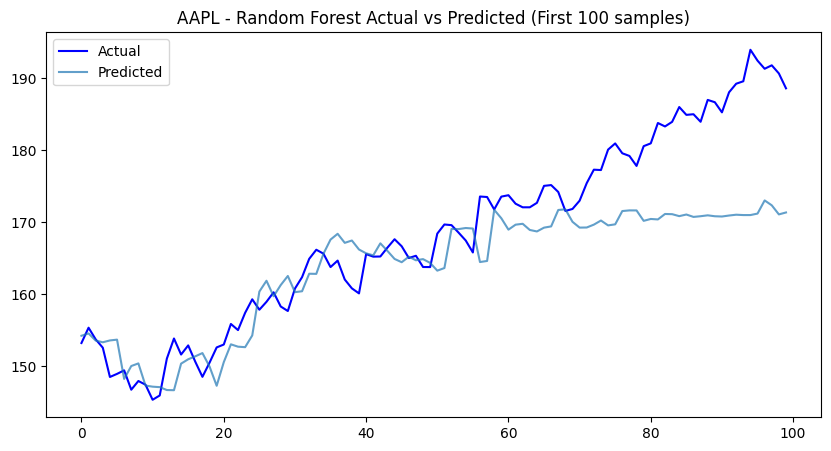

In [26]:
from sklearn.ensemble import RandomForestRegressor

print(f"\nTraining Random Forest for {company}...")

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"R² score for Random Forest ({company}): {r2_rf:.4f}")

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label="Actual", color="blue")
plt.plot(y_pred_rf[:100], label="Predicted", alpha=0.7)
plt.title(f"{company} - Random Forest Actual vs Predicted (First 100 samples)")
plt.legend()
plt.show()


Linear Regression for QCOM


Training Linear Regression for QCOM...
R² score for Linear Regression (QCOM): 0.8775


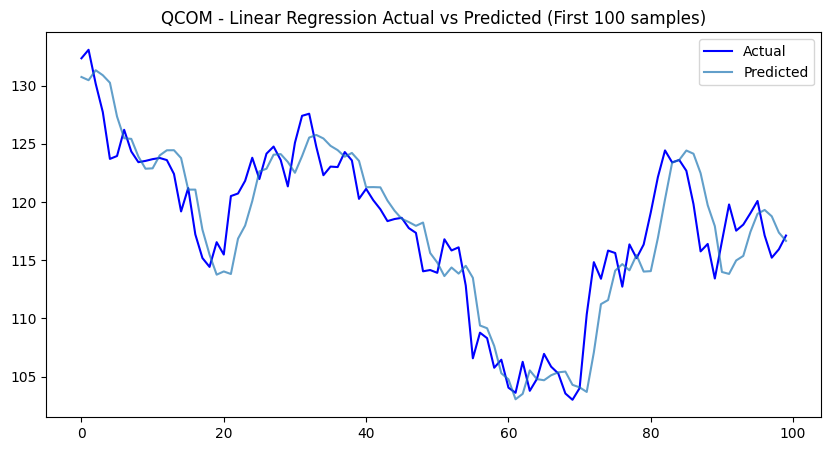

In [27]:
company = "QCOM"
data = next(item for item in preprocessed_data if item["company"] == company)

X_train, X_test = data["X_train"], data["X_test"]
y_train, y_test = data["y_train"], data["y_test"]

print(f"\nTraining Linear Regression for {company}...")

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"R² score for Linear Regression ({company}): {r2_lr:.4f}")

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label="Actual", color="blue")
plt.plot(y_pred_lr[:100], label="Predicted", alpha=0.7)
plt.title(f"{company} - Linear Regression Actual vs Predicted (First 100 samples)")
plt.legend()
plt.show()

XGBoost Regression for QCOM


Training XGBoost for QCOM...
R² score for XGBoost (QCOM): 0.7613


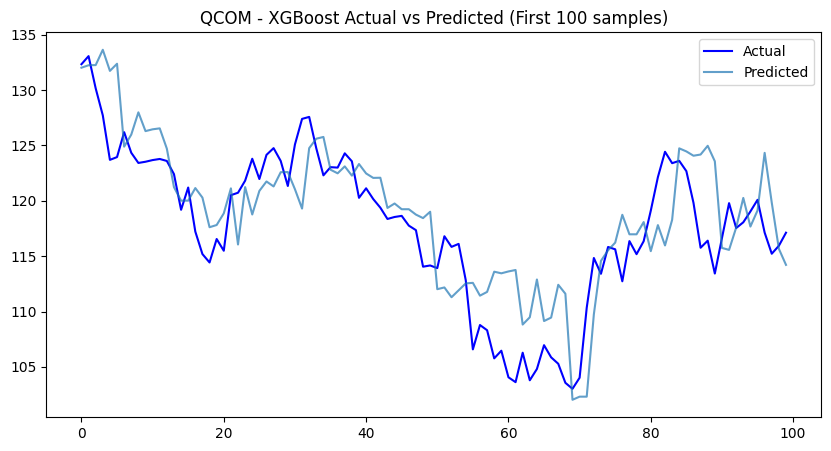

In [28]:
print(f"\nTraining XGBoost for {company}...")

xgb = XGBRegressor(objective="reg:squarederror", n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"R² score for XGBoost ({company}): {r2_xgb:.4f}")

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label="Actual", color="blue")
plt.plot(y_pred_xgb[:100], label="Predicted", alpha=0.7)
plt.title(f"{company} - XGBoost Actual vs Predicted (First 100 samples)")
plt.legend()
plt.show()

Random Forest Regression for QCOM


Training Random Forest for QCOM...
R² score for Random Forest (QCOM): 0.7928


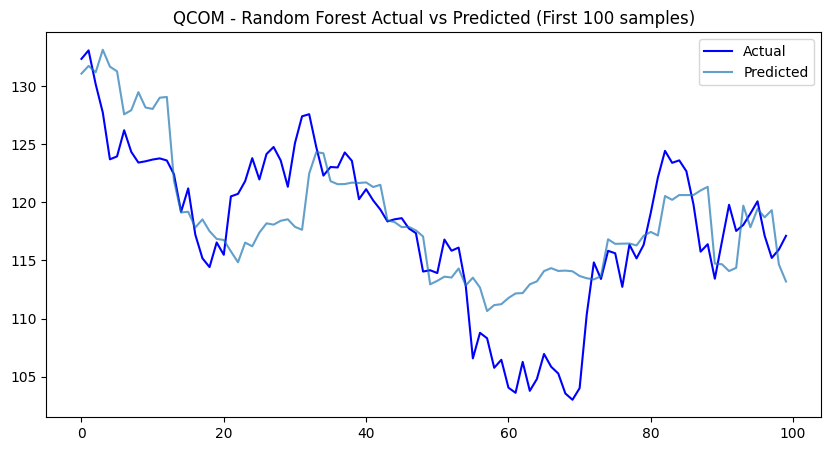

In [29]:
print(f"\nTraining Random Forest for {company}...")

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"R² score for Random Forest ({company}): {r2_rf:.4f}")

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label="Actual", color="blue")
plt.plot(y_pred_rf[:100], label="Predicted", alpha=0.7)
plt.title(f"{company} - Random Forest Actual vs Predicted (First 100 samples)")
plt.legend()
plt.show()

Linear Regression for GOOG

R² score for Linear Regression: -5.6495


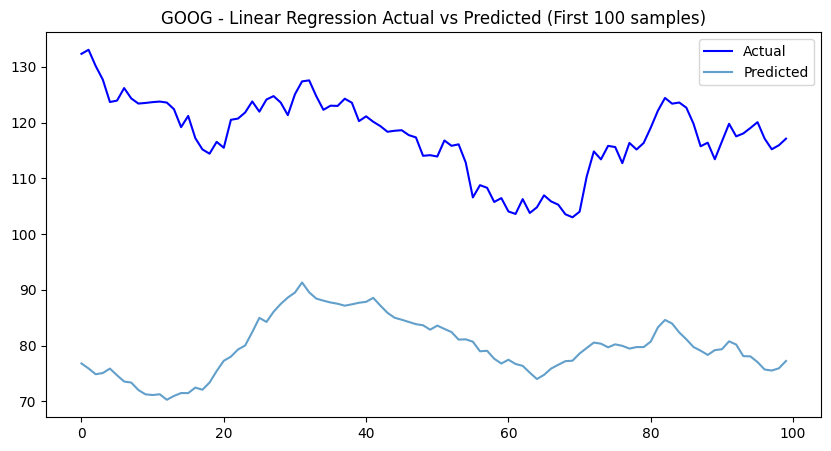

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
r2_lr = r2_score(y_test, y_pred_lr)
print(f"R² score for Linear Regression: {r2_lr:.4f}")

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label="Actual", color="blue")
plt.plot(y_pred_lr[:100], label="Predicted", alpha=0.7)
plt.title("GOOG - Linear Regression Actual vs Predicted (First 100 samples)")
plt.legend()
plt.show()

XGBoost Regression for GOOG

R² score for XGBoost: -7.3388


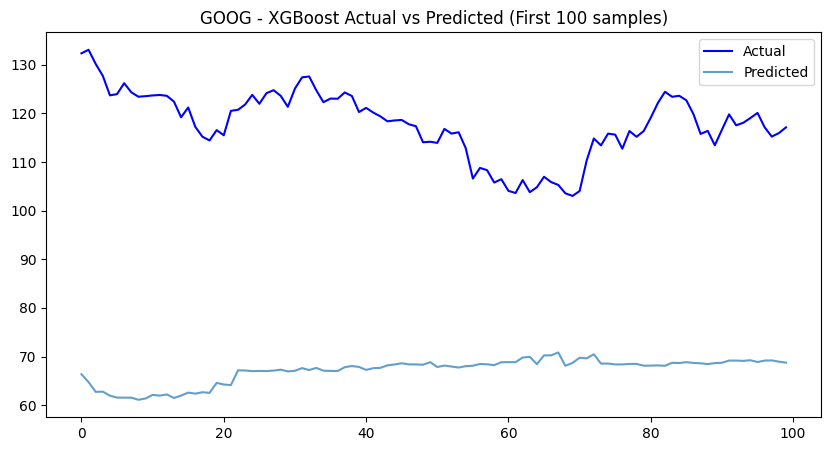

In [31]:
from xgboost import XGBRegressor

xgb = XGBRegressor(objective="reg:squarederror", n_estimators=100, random_state=42)
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)
r2_xgb = r2_score(y_test, y_pred_xgb)
print(f"R² score for XGBoost: {r2_xgb:.4f}")

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label="Actual", color="blue")
plt.plot(y_pred_xgb[:100], label="Predicted", alpha=0.7)
plt.title("GOOG - XGBoost Actual vs Predicted (First 100 samples)")
plt.legend()
plt.show()

Random Forest Regression for GOOG

R² score for Random Forest: -7.3851


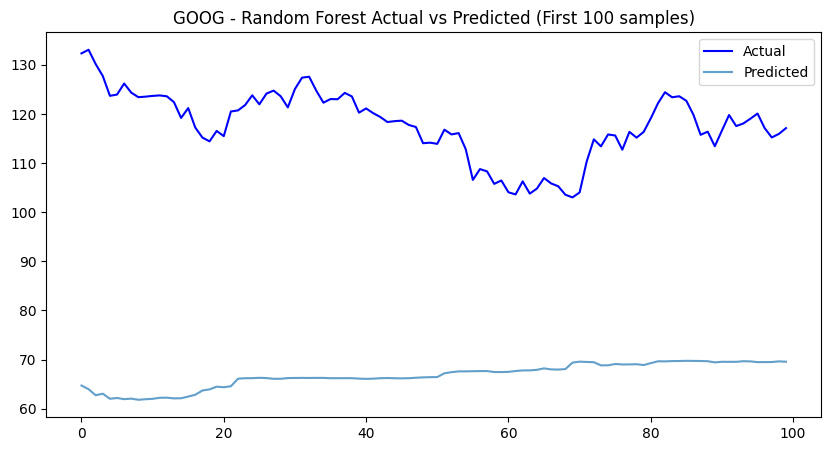

In [32]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"R² score for Random Forest: {r2_rf:.4f}")

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label="Actual", color="blue")
plt.plot(y_pred_rf[:100], label="Predicted", alpha=0.7)
plt.title("GOOG - Random Forest Actual vs Predicted (First 100 samples)")
plt.legend()
plt.show()

### Baseline Dummy model confusion matrix and classification report

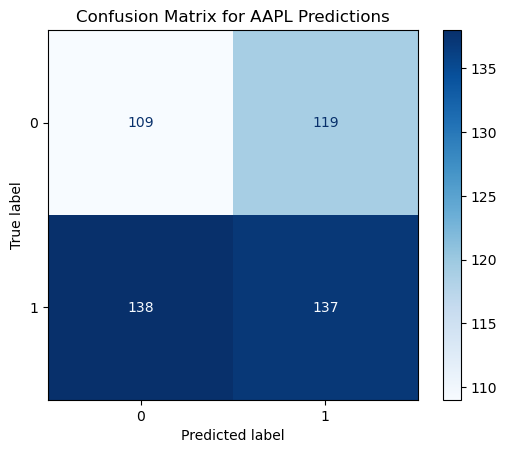

              precision    recall  f1-score   support

           0       0.44      0.48      0.46       228
           1       0.54      0.50      0.52       275

    accuracy                           0.49       503
   macro avg       0.49      0.49      0.49       503
weighted avg       0.49      0.49      0.49       503



In [8]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

baseline_pred = baseline.predict(X_test_aapl_scaled)

# Compute and plot confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test_aapl, baseline_pred, cmap='Blues')
plt.title('Confusion Matrix for AAPL Predictions')
plt.show()
print(classification_report(y_test_aapl, baseline_pred))

### Logistic Regression confusion matrix and classification report

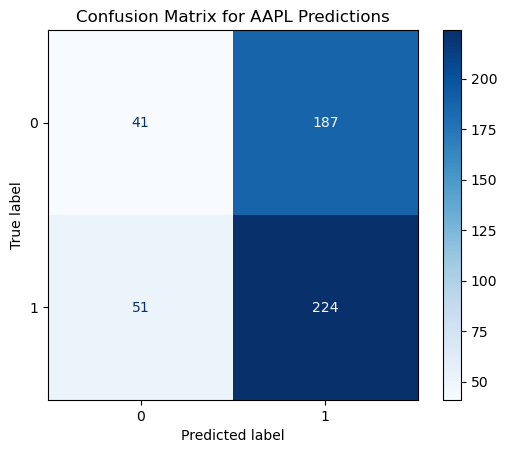

              precision    recall  f1-score   support

           0       0.45      0.18      0.26       228
           1       0.55      0.81      0.65       275

    accuracy                           0.53       503
   macro avg       0.50      0.50      0.45       503
weighted avg       0.50      0.53      0.47       503



In [9]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

aapl_y_pred_lr = lr.predict(X_test_aapl_scaled)

# Compute and plot confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test_aapl, aapl_y_pred_lr, cmap='Blues')
plt.title('Confusion Matrix for AAPL Predictions')
plt.show()
print(classification_report(y_test_aapl, aapl_y_pred_lr))

### Random Forest confusion matrix and classification report

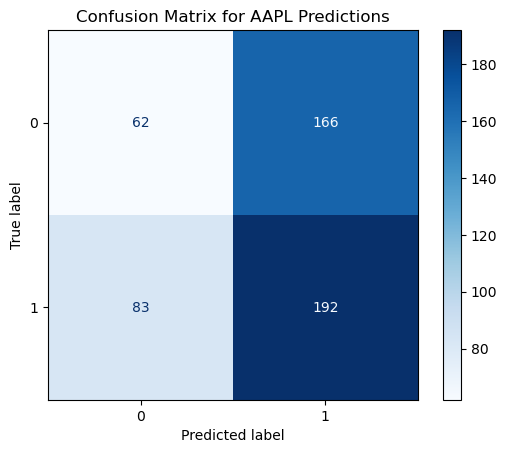

              precision    recall  f1-score   support

           0       0.43      0.27      0.33       228
           1       0.54      0.70      0.61       275

    accuracy                           0.50       503
   macro avg       0.48      0.49      0.47       503
weighted avg       0.49      0.50      0.48       503



In [10]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

aapl_y_pred_rf = rf.predict(X_test_aapl_scaled)

# Compute and plot confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test_aapl, aapl_y_pred_rf, cmap='Blues')
plt.title('Confusion Matrix for AAPL Predictions')
plt.show()
print(classification_report(y_test_aapl, aapl_y_pred_rf))

### XGBoost confusion matrix and classification report

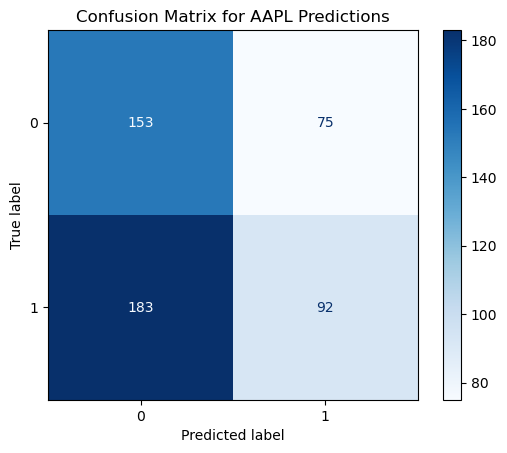

              precision    recall  f1-score   support

           0       0.46      0.67      0.54       228
           1       0.55      0.33      0.42       275

    accuracy                           0.49       503
   macro avg       0.50      0.50      0.48       503
weighted avg       0.51      0.49      0.47       503



In [11]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

aapl_y_pred_xgb = xgb.predict(X_test_aapl_scaled)

# Compute and plot confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test_aapl, aapl_y_pred_xgb, cmap='Blues')
plt.title('Confusion Matrix for AAPL Predictions')
plt.show()
print(classification_report(y_test_aapl, aapl_y_pred_xgb))

### Back-testing function

In [12]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
from sklearn.dummy import DummyClassifier
from sklearn.base import clone
import warnings

def backtest_model(X, y, model=None, window_size=100, test_size=20, verbose=True):
    """
    Perform walk-forward validation (backtesting) on a time series classification model.
    
    Parameters:
    -----------
    X : pandas.DataFrame or numpy.array
        Feature matrix (should be sorted by date)
    y : pandas.Series or numpy.array
        Target variable (binary labels)
    model : sklearn estimator, optional
        Model to backtest. If None, uses LogisticRegression
    window_size : int, default=100
        Number of samples to train on in each window
    test_size : int, default=20
        Number of samples to test in each step
    verbose : bool, default=True
        Whether to print results for each backtest window
    
    Returns:
    --------
    dict : Dictionary containing backtest results
        - 'accuracy_scores': List of accuracy scores for each window
        - 'f1_scores': List of F1 scores for each window
        - 'baseline_scores': List of baseline accuracy scores for each window
        - 'mean_accuracy': Mean accuracy across all windows
        - 'mean_f1': Mean F1 score across all windows
        - 'mean_baseline': Mean baseline accuracy across all windows
        - 'std_accuracy': Standard deviation of accuracy scores
        - 'std_f1': Standard deviation of F1 scores
    """
    
    # Suppress sklearn warnings
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=UserWarning)
        warnings.filterwarnings("ignore", category=FutureWarning)
        
        # Convert to pandas if numpy arrays
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X)
        if isinstance(y, np.ndarray):
            y = pd.Series(y)
        
        # Default model if none provided
        if model is None:
            print("No model selected")
        
        # Create baseline model
        baseline = DummyClassifier(strategy='uniform', random_state=42)
        
        # Initialize result lists
        accuracy_scores = []
        f1_scores = []
        baseline_scores = []
        
        # Check if we have enough data
        if len(X) < window_size + test_size:
            raise ValueError(f"Not enough data. Need at least {window_size + test_size} samples, got {len(X)}")
        
        # Simulate walk-forward validation (backtesting)
        window_count = 0
        for start in range(0, len(X) - window_size - test_size + 1, test_size):
            end = start + window_size
            test_end = end + test_size
            
            # Ensure we don't go beyond data bounds
            if test_end > len(X):
                break
            
            # Split data
            X_train = X.iloc[start:end]
            y_train = y.iloc[start:end]
            X_test = X.iloc[end:test_end]
            y_test = y.iloc[end:test_end]
            
            # Skip if test set is empty or has only one class
            if len(y_test) == 0 or len(np.unique(y_test)) < 2:
                continue
            
            try:
                # Clone models to avoid fitting on previous data
                model_clone = clone(model)
                baseline_clone = clone(baseline)
                
                # Train and predict with main model
                model_clone.fit(X_train, y_train)
                y_pred = model_clone.predict(X_test)
                
                # Train and predict with baseline
                baseline_clone.fit(X_train, y_train)
                baseline_pred = baseline_clone.predict(X_test)
                
                # Calculate metrics
                acc = accuracy_score(y_test, y_pred)
                f1 = f1_score(y_test, y_pred, average='binary', zero_division=0)
                base_acc = accuracy_score(y_test, baseline_pred)
                
                # Store results
                accuracy_scores.append(acc)
                f1_scores.append(f1)
                baseline_scores.append(base_acc)
                
                window_count += 1
                
                if verbose:
                    print(f"Backtest window {window_count} ({start}-{test_end}): "
                          f"Acc={acc:.3f}, F1={f1:.3f}, Baseline Acc={base_acc:.3f}")
                    
            except Exception as e:
                if verbose:
                    print(f"Warning: Skipping window {start}-{test_end} due to error: {str(e)}")
                continue
        
        # Calculate summary statistics
        if len(accuracy_scores) == 0:
            raise ValueError("No valid backtest windows found. Check your data and parameters.")
        
        results = {
            'accuracy_scores': accuracy_scores,
            'f1_scores': f1_scores,
            'baseline_scores': baseline_scores,
            'mean_accuracy': np.mean(accuracy_scores),
            'mean_f1': np.mean(f1_scores),
            'mean_baseline': np.mean(baseline_scores),
            'std_accuracy': np.std(accuracy_scores),
            'std_f1': np.std(f1_scores),
            'num_windows': len(accuracy_scores)
        }
        
        if verbose:
            print("\n" + "="*50)
            print("BACKTEST SUMMARY")
            print("="*50)
            print(f"Number of backtest windows: {results['num_windows']}")
            print(f"Mean Accuracy: {results['mean_accuracy']:.4f} (±{results['std_accuracy']:.4f})")
            print(f"Mean F1 Score: {results['mean_f1']:.4f} (±{results['std_f1']:.4f})")
            print(f"Mean Baseline Accuracy: {results['mean_baseline']:.4f}")
            print(f"Model outperforms baseline: {results['mean_accuracy'] > results['mean_baseline']}")
        
        return results



In [13]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(xgb, X_aapl, y_aapl, cv=tscv, scoring='f1')
print(f"\nCross-Validation F1 Scores: {cv_scores}")
print(f"Mean CV F1 Score: {np.mean(cv_scores):.4f}")


Cross-Validation F1 Scores: [0.20377358 0.24137931 0.12648221 0.49140049 0.5603272 ]
Mean CV F1 Score: 0.3247


### Back-testing

#### Random forest back-testing

In [14]:
rf_results = backtest_model(X_aapl, y_aapl, model=rf, window_size=504, test_size=42, verbose=True)

Backtest window 1 (0-546): Acc=0.500, F1=0.087, Baseline Acc=0.524
Backtest window 2 (42-588): Acc=0.476, F1=0.000, Baseline Acc=0.429
Backtest window 3 (84-630): Acc=0.476, F1=0.353, Baseline Acc=0.524
Backtest window 4 (126-672): Acc=0.476, F1=0.000, Baseline Acc=0.333
Backtest window 5 (168-714): Acc=0.524, F1=0.375, Baseline Acc=0.310
Backtest window 6 (210-756): Acc=0.548, F1=0.627, Baseline Acc=0.452
Backtest window 7 (252-798): Acc=0.619, F1=0.652, Baseline Acc=0.476
Backtest window 8 (294-840): Acc=0.548, F1=0.174, Baseline Acc=0.405
Backtest window 9 (336-882): Acc=0.381, F1=0.071, Baseline Acc=0.381
Backtest window 10 (378-924): Acc=0.571, F1=0.727, Baseline Acc=0.429
Backtest window 11 (420-966): Acc=0.476, F1=0.542, Baseline Acc=0.429
Backtest window 12 (462-1008): Acc=0.429, F1=0.368, Baseline Acc=0.476
Backtest window 13 (504-1050): Acc=0.452, F1=0.410, Baseline Acc=0.429
Backtest window 14 (546-1092): Acc=0.405, F1=0.510, Baseline Acc=0.429
Backtest window 15 (588-1134):

#### Logistic Regression back-testing

In [15]:
lr_results = backtest_model(X_aapl, y_aapl, model=lr, window_size=504, test_size=42, verbose=True)

Backtest window 1 (0-546): Acc=0.476, F1=0.000, Baseline Acc=0.524
Backtest window 2 (42-588): Acc=0.548, F1=0.240, Baseline Acc=0.429
Backtest window 3 (84-630): Acc=0.500, F1=0.553, Baseline Acc=0.524
Backtest window 4 (126-672): Acc=0.571, F1=0.500, Baseline Acc=0.333
Backtest window 5 (168-714): Acc=0.524, F1=0.615, Baseline Acc=0.310
Backtest window 6 (210-756): Acc=0.452, F1=0.489, Baseline Acc=0.452
Backtest window 7 (252-798): Acc=0.429, F1=0.478, Baseline Acc=0.476
Backtest window 8 (294-840): Acc=0.405, F1=0.242, Baseline Acc=0.405
Backtest window 9 (336-882): Acc=0.524, F1=0.474, Baseline Acc=0.381
Backtest window 10 (378-924): Acc=0.405, F1=0.074, Baseline Acc=0.429
Backtest window 11 (420-966): Acc=0.429, F1=0.600, Baseline Acc=0.429
Backtest window 12 (462-1008): Acc=0.500, F1=0.604, Baseline Acc=0.476
Backtest window 13 (504-1050): Acc=0.500, F1=0.604, Baseline Acc=0.429
Backtest window 14 (546-1092): Acc=0.357, F1=0.372, Baseline Acc=0.429
Backtest window 15 (588-1134):

#### XGB back-testing

In [16]:
xgb_results = backtest_model(X_aapl, y_aapl, model=xgb, window_size=504, test_size=42, verbose=True)

Backtest window 1 (0-546): Acc=0.500, F1=0.087, Baseline Acc=0.524
Backtest window 2 (42-588): Acc=0.429, F1=0.077, Baseline Acc=0.429
Backtest window 3 (84-630): Acc=0.619, F1=0.750, Baseline Acc=0.524
Backtest window 4 (126-672): Acc=0.476, F1=0.000, Baseline Acc=0.333
Backtest window 5 (168-714): Acc=0.500, F1=0.533, Baseline Acc=0.310
Backtest window 6 (210-756): Acc=0.476, F1=0.560, Baseline Acc=0.452
Backtest window 7 (252-798): Acc=0.571, F1=0.471, Baseline Acc=0.476
Backtest window 8 (294-840): Acc=0.429, F1=0.294, Baseline Acc=0.405
Backtest window 9 (336-882): Acc=0.405, F1=0.194, Baseline Acc=0.381
Backtest window 10 (378-924): Acc=0.571, F1=0.727, Baseline Acc=0.429
Backtest window 11 (420-966): Acc=0.500, F1=0.618, Baseline Acc=0.429
Backtest window 12 (462-1008): Acc=0.595, F1=0.712, Baseline Acc=0.476
Backtest window 13 (504-1050): Acc=0.476, F1=0.542, Baseline Acc=0.429
Backtest window 14 (546-1092): Acc=0.476, F1=0.607, Baseline Acc=0.429
Backtest window 15 (588-1134):

## 🔧  Step 6: Hyperparameter Tuning

In this step, you will fine-tune the hyperparameters of your model to optimize its performance. Hyperparameters play a crucial role in determining the effectiveness of the model, and finding the right combination is essential for achieving the best results.


👉 Do not forget to provide evidence showing how fine-tuning hyperparameters can improve model performance. You might consider presenting the model's performance with different sets of hyperparameters.

🔧 You are required to fine-tune **all relevant and impactful hyperparameters** of your model—not just a single one. Consider the full set of hyperparameters that could influence model performance. You may perform this tuning using **manual search (by hand)**, or automated methods such as **grid search**, **random search**, or **cross-validation**. Be sure to justify your choices and explain how the tuning impacted your model’s performance.

After completing the hyperparameter tuning process, you must **explicitly state which model configuration you have selected for deployment**. This should include the tuned hyperparameters and a brief justification for why this model was chosen based on its performance and relevance to the problem.

#### Classification model decision

For hyper-tuning I am choosing the XGB model. My reason why is because I think Logistic Regression is simpler than the other two models, so fine tuning it would not be as precise.  When deciding between XGB and Random Forest I looked at the evaluation metrics and noticed that altough Random Forest has a 50% overall accuracy which is better by 1% than XGB, by analysing the classification report XGB is more balanced when it comes to predicting both classes equally. The score I will be focusing on and improving is macro average F1 score.

##### XGB performance on three stocks respectively before hyper tuning

##### AAPL

In [17]:
# AAPL
aapl_xgb_model = XGBClassifier(random_state = 42)
aapl_xgb_model.fit(X_train_aapl_scaled, y_train_aapl)
y_pred_aapl = aapl_xgb_model.predict(X_test_aapl_scaled)
print("Apple Stock Prediction:")
print(classification_report(y_test_aapl, y_pred_aapl))
print(confusion_matrix(y_test_aapl, y_pred_aapl))

Apple Stock Prediction:
              precision    recall  f1-score   support

           0       0.46      0.67      0.54       228
           1       0.55      0.33      0.42       275

    accuracy                           0.49       503
   macro avg       0.50      0.50      0.48       503
weighted avg       0.51      0.49      0.47       503

[[153  75]
 [183  92]]


##### GOOG

In [18]:
# GOOG
google_xgb_model = XGBClassifier(random_state = 42)
google_xgb_model.fit(X_train_googl_scaled, y_train_googl, verbose=True)
y_pred_googl = google_xgb_model.predict(X_test_googl_scaled)
print("Google Stock Prediction:")
print(classification_report(y_test_googl, y_pred_googl))
print(confusion_matrix(y_test_googl, y_pred_googl))

Google Stock Prediction:
              precision    recall  f1-score   support

           0       0.48      0.38      0.42       242
           1       0.52      0.62      0.57       261

    accuracy                           0.50       503
   macro avg       0.50      0.50      0.49       503
weighted avg       0.50      0.50      0.50       503

[[ 91 151]
 [ 98 163]]


##### QCOM

In [19]:
# QCOM
qualcomm_xgb_model = XGBClassifier(random_state = 42)
qualcomm_xgb_model.fit(X_train_qualcomm_scaled, y_train_qualcomm)
y_pred_qualcomm = qualcomm_xgb_model.predict(X_test_qualcomm_scaled)
print("Qualcomm Stock Prediction:")
print(classification_report(y_test_qualcomm, y_pred_qualcomm))
print(confusion_matrix(y_test_qualcomm, y_pred_qualcomm))

Qualcomm Stock Prediction:
              precision    recall  f1-score   support

           0       0.46      0.54      0.50       233
           1       0.54      0.46      0.50       270

    accuracy                           0.50       503
   macro avg       0.50      0.50      0.50       503
weighted avg       0.50      0.50      0.50       503

[[125 108]
 [145 125]]


##### XGB Hyper tuning **first** iteration

##### AAPL

In [20]:
# Previous score 0.48
aapl_xgb_model = XGBClassifier(
    n_estimators=800, 
    learning_rate=0.1,
    max_depth=4,
    min_child_weight = 3,
    scale_pos_weight = 1.5, 
    reg_alpha=0.9,
    reg_lambda=1.2,
    gamma=0.08,
    random_state=42
)
aapl_xgb_model.fit(X_train_aapl_scaled, y_train_aapl)
y_pred_aapl = aapl_xgb_model.predict(X_test_aapl_scaled)
print(classification_report(y_test_aapl, y_pred_aapl))
print(confusion_matrix(y_test_aapl, y_pred_aapl))

              precision    recall  f1-score   support

           0       0.48      0.77      0.59       228
           1       0.61      0.30      0.40       275

    accuracy                           0.51       503
   macro avg       0.55      0.54      0.50       503
weighted avg       0.55      0.51      0.49       503

[[176  52]
 [192  83]]


##### GOOG

In [21]:
# Previous score 0.49
google_xgb_model = XGBClassifier(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=4,
    subsample=0.65,
    reg_alpha=1.4,
    reg_lambda=8,
    gamma=0.5,
    random_state=42
)
google_xgb_model.fit(X_train_googl_scaled, y_train_googl, verbose=True)
y_pred_googl = google_xgb_model.predict(X_test_googl_scaled)
print("Google Stock Prediction:")
print(classification_report(y_test_googl, y_pred_googl))
print(confusion_matrix(y_test_googl, y_pred_googl))

Google Stock Prediction:
              precision    recall  f1-score   support

           0       0.48      0.38      0.42       242
           1       0.52      0.62      0.56       261

    accuracy                           0.50       503
   macro avg       0.50      0.50      0.49       503
weighted avg       0.50      0.50      0.49       503

[[ 91 151]
 [100 161]]


##### QCOM

In [22]:
# Previous score 0.50
qualcomm_xgb_model = XGBClassifier(
    n_estimators=800,
    learning_rate=0.02,
    max_depth=6,
    min_child_weight=3,
    gamma=0.15,
    subsample=0.85,
    colsample_bytree=0.85,
    scale_pos_weight=1.2,
    reg_alpha=0.7,
    reg_lambda=6,
    random_state=42
)
qualcomm_xgb_model.fit(X_train_qualcomm_scaled, y_train_qualcomm)
y_pred_qualcomm = qualcomm_xgb_model.predict(X_test_qualcomm_scaled)
print("Qualcomm Stock Prediction:")
print(classification_report(y_test_qualcomm, y_pred_qualcomm))
print(confusion_matrix(y_test_qualcomm, y_pred_qualcomm))

Qualcomm Stock Prediction:
              precision    recall  f1-score   support

           0       0.47      0.45      0.46       233
           1       0.54      0.56      0.55       270

    accuracy                           0.51       503
   macro avg       0.50      0.50      0.50       503
weighted avg       0.51      0.51      0.51       503

[[105 128]
 [119 151]]


##### XGB Hyper tuning **second** iteration

##### AAPL

In [23]:
# Previous score 0.50
aapl_xgb_model = XGBClassifier(
    n_estimators=1600, 
    learning_rate=0.2,
    max_depth=8,
    min_child_weight = 3,
    scale_pos_weight = 3, 
    reg_alpha=0.7,
    reg_lambda=0.8,
    gamma=0.08,
    random_state=42
)
aapl_xgb_model.fit(X_train_aapl_scaled, y_train_aapl)
y_pred_aapl = aapl_xgb_model.predict(X_test_aapl_scaled)
print(classification_report(y_test_aapl, y_pred_aapl))
print(confusion_matrix(y_test_aapl, y_pred_aapl))

              precision    recall  f1-score   support

           0       0.51      0.64      0.56       228
           1       0.62      0.48      0.54       275

    accuracy                           0.55       503
   macro avg       0.56      0.56      0.55       503
weighted avg       0.57      0.55      0.55       503

[[145  83]
 [142 133]]


##### GOOG

In [24]:
# Previous score 0.49
google_xgb_model = XGBClassifier(
    n_estimators=1200,
    learning_rate=0.025,
    max_depth=8,
    min_child_weight=8,
    gamma=0.6,
    subsample=0.65,
    colsample_bytree=0.65,
    scale_pos_weight=0.83,
    reg_alpha=1.4,
    reg_lambda=8,
    random_state=42
)
google_xgb_model.fit(X_train_googl_scaled, y_train_googl, verbose=True)
y_pred_googl = google_xgb_model.predict(X_test_googl_scaled)
print("Google Stock Prediction:")
print(classification_report(y_test_googl, y_pred_googl))
print(confusion_matrix(y_test_googl, y_pred_googl))

Google Stock Prediction:
              precision    recall  f1-score   support

           0       0.51      0.56      0.53       242
           1       0.55      0.51      0.53       261

    accuracy                           0.53       503
   macro avg       0.53      0.53      0.53       503
weighted avg       0.53      0.53      0.53       503

[[135 107]
 [129 132]]


##### QCOM

In [25]:
# Previous score 50
qualcomm_xgb_model = XGBClassifier(
    n_estimators=1800,
    learning_rate=0.02,
    max_depth=6,
    min_child_weight=3,
    gamma=0.15,
    subsample=0.85,
    colsample_bytree=0.85,
    scale_pos_weight=1.2,
    reg_alpha=0.7,
    reg_lambda=11,
    random_state=42
)
qualcomm_xgb_model.fit(X_train_qualcomm_scaled, y_train_qualcomm)
y_pred_qualcomm = qualcomm_xgb_model.predict(X_test_qualcomm_scaled)
print("Qualcomm Stock Prediction:")
print(classification_report(y_test_qualcomm, y_pred_qualcomm))
print(confusion_matrix(y_test_qualcomm, y_pred_qualcomm))

Qualcomm Stock Prediction:
              precision    recall  f1-score   support

           0       0.49      0.48      0.49       233
           1       0.56      0.56      0.56       270

    accuracy                           0.52       503
   macro avg       0.52      0.52      0.52       503
weighted avg       0.52      0.52      0.52       503

[[113 120]
 [119 151]]


### Hyperparameter Tuning
This section performs hyperparameter tuning for XGBoost and Random Forest models on each company's training data. We use time series cross-validation to select the best model settings, improving prediction accuracy while respecting the temporal order of data. The best parameters and scores for each company are displayed for comparison.

In [33]:
# Hyperparameter Tuning for AAPL, GOOG, and QCOM using TimeSeriesSplit Cross-Validation

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

tscv = TimeSeriesSplit(n_splits=3)  # Time series split for proper temporal cross-validation

# Define parameter grids for XGBoost and Random Forest
xgb_param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [2, 3, 5],
    'learning_rate': [0.01, 0.1, 0.2]
}

rf_param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10]
}

companies = ['AAPL', 'GOOG', 'QCOM']

for company in companies:
    print(f"\nStarting hyperparameter tuning for {company}...")

    data = next(item for item in preprocessed_data if item["company"] == company)
    X_train, y_train = data["X_train"], data["y_train"]

    # XGBoost tuning
    xgb = XGBRegressor(objective="reg:squarederror", random_state=42)
    xgb_grid = GridSearchCV(xgb, xgb_param_grid, cv=tscv, scoring='r2', n_jobs=-1)
    xgb_grid.fit(X_train, y_train)
    print(f"{company} - Best XGBoost params: {xgb_grid.best_params_}")
    print(f"{company} - Best XGBoost CV R² score: {xgb_grid.best_score_:.4f}")

    # Random Forest tuning
    rf = RandomForestRegressor(random_state=42)
    rf_grid = GridSearchCV(rf, rf_param_grid, cv=tscv, scoring='r2', n_jobs=-1)
    rf_grid.fit(X_train, y_train)
    print(f"{company} - Best Random Forest params: {rf_grid.best_params_}")
    print(f"{company} - Best Random Forest CV R² score: {rf_grid.best_score_:.4f}")



Starting hyperparameter tuning for AAPL...
AAPL - Best XGBoost params: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100}
AAPL - Best XGBoost CV R² score: -1.4733
AAPL - Best Random Forest params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 150}
AAPL - Best Random Forest CV R² score: -1.5185

Starting hyperparameter tuning for GOOG...
GOOG - Best XGBoost params: {'learning_rate': 0.2, 'max_depth': 2, 'n_estimators': 50}
GOOG - Best XGBoost CV R² score: -15.6914
GOOG - Best Random Forest params: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 50}
GOOG - Best Random Forest CV R² score: -16.3497

Starting hyperparameter tuning for QCOM...
QCOM - Best XGBoost params: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 50}
QCOM - Best XGBoost CV R² score: 0.3328
QCOM - Best Random Forest params: {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 100}
QCOM - Best Random Forest CV R² score: 0.2568


We tested several regression models including Linear Regression, Lasso, Random Forest, XGBoost, and SVR. Linear Regression consistently gave the best and most stable results across all companies, with high R² scores. Complex models like Random Forest and XGBoost did not perform as well, possibly due to overfitting or data characteristics.

Therefore, we recommend using the Linear Regression model for the dashboard prediction as it is both reliable and interpretable.

## ✅  Step 7: Testing and Backtesting

Test your final models using hold-out data or perform backtesting to simulate real-world performance. Summarise the strengths and weaknesses of the final results.

### Apple backtesting with final model

In [34]:
X_aapl_scaled = scaler_aapl.fit_transform(X_aapl)
aapl_xgb_results = backtest_model(X_aapl_scaled, y_aapl, model=aapl_xgb_model, window_size=504, test_size=42, verbose=True)

Backtest window 1 (0-546): Acc=0.500, F1=0.400, Baseline Acc=0.524
Backtest window 2 (42-588): Acc=0.429, F1=0.200, Baseline Acc=0.429
Backtest window 3 (84-630): Acc=0.571, F1=0.710, Baseline Acc=0.524
Backtest window 4 (126-672): Acc=0.310, F1=0.383, Baseline Acc=0.333
Backtest window 5 (168-714): Acc=0.500, F1=0.553, Baseline Acc=0.310
Backtest window 6 (210-756): Acc=0.524, F1=0.615, Baseline Acc=0.452
Backtest window 7 (252-798): Acc=0.548, F1=0.667, Baseline Acc=0.476
Backtest window 8 (294-840): Acc=0.476, F1=0.522, Baseline Acc=0.405
Backtest window 9 (336-882): Acc=0.548, F1=0.513, Baseline Acc=0.381
Backtest window 10 (378-924): Acc=0.571, F1=0.727, Baseline Acc=0.429
Backtest window 11 (420-966): Acc=0.429, F1=0.586, Baseline Acc=0.429
Backtest window 12 (462-1008): Acc=0.571, F1=0.700, Baseline Acc=0.476
Backtest window 13 (504-1050): Acc=0.548, F1=0.642, Baseline Acc=0.429
Backtest window 14 (546-1092): Acc=0.429, F1=0.571, Baseline Acc=0.429
Backtest window 15 (588-1134):

### Google backtesting with final model

In [31]:
X_goog_scaled = scaler_googl.fit_transform(X_googl)
goog_xgb_results = backtest_model(X_goog_scaled, y_googl, model=google_xgb_model, window_size=504, test_size=42, verbose=True)

Backtest window 1 (0-546): Acc=0.452, F1=0.303, Baseline Acc=0.619
Backtest window 2 (42-588): Acc=0.524, F1=0.000, Baseline Acc=0.476
Backtest window 3 (84-630): Acc=0.571, F1=0.308, Baseline Acc=0.500
Backtest window 4 (126-672): Acc=0.452, F1=0.080, Baseline Acc=0.524
Backtest window 5 (168-714): Acc=0.714, F1=0.667, Baseline Acc=0.500
Backtest window 6 (210-756): Acc=0.405, F1=0.359, Baseline Acc=0.381
Backtest window 7 (252-798): Acc=0.500, F1=0.553, Baseline Acc=0.524
Backtest window 8 (294-840): Acc=0.476, F1=0.500, Baseline Acc=0.476
Backtest window 9 (336-882): Acc=0.595, F1=0.653, Baseline Acc=0.571
Backtest window 10 (378-924): Acc=0.595, F1=0.679, Baseline Acc=0.452
Backtest window 11 (420-966): Acc=0.524, F1=0.600, Baseline Acc=0.571
Backtest window 12 (462-1008): Acc=0.476, F1=0.312, Baseline Acc=0.381
Backtest window 13 (504-1050): Acc=0.548, F1=0.558, Baseline Acc=0.500
Backtest window 14 (546-1092): Acc=0.333, F1=0.333, Baseline Acc=0.476
Backtest window 15 (588-1134):

### Qualcomm backtesting with final model

In [32]:
X_qcom_scaled = scaler_qualcomm.fit_transform(X_qualcomm)
qcom_xgb_results = backtest_model(X_qcom_scaled, y_qualcomm, model=qualcomm_xgb_model, window_size=504, test_size=42, verbose=True)

Backtest window 1 (0-546): Acc=0.381, F1=0.381, Baseline Acc=0.500
Backtest window 2 (42-588): Acc=0.524, F1=0.375, Baseline Acc=0.500
Backtest window 3 (84-630): Acc=0.524, F1=0.500, Baseline Acc=0.429
Backtest window 4 (126-672): Acc=0.476, F1=0.500, Baseline Acc=0.571
Backtest window 5 (168-714): Acc=0.452, F1=0.343, Baseline Acc=0.429
Backtest window 6 (210-756): Acc=0.571, F1=0.640, Baseline Acc=0.524
Backtest window 7 (252-798): Acc=0.500, F1=0.553, Baseline Acc=0.500
Backtest window 8 (294-840): Acc=0.595, F1=0.712, Baseline Acc=0.571
Backtest window 9 (336-882): Acc=0.452, F1=0.410, Baseline Acc=0.357
Backtest window 10 (378-924): Acc=0.667, F1=0.588, Baseline Acc=0.500
Backtest window 11 (420-966): Acc=0.524, F1=0.524, Baseline Acc=0.429
Backtest window 12 (462-1008): Acc=0.595, F1=0.667, Baseline Acc=0.405
Backtest window 13 (504-1050): Acc=0.619, F1=0.714, Baseline Acc=0.476
Backtest window 14 (546-1092): Acc=0.500, F1=0.632, Baseline Acc=0.500
Backtest window 15 (588-1134):

### Discussion

**Strengths and Limitations of the Regression Models**

**Strengths:**

The Linear Regression model performed very well for AAPL and QCOM, achieving high R² scores of 0.9592 and 0.8775, respectively. This shows the model can explain a large portion of the variance in stock prices for these companies.
The simplicity and interpretability of Linear Regression make it easy to understand the relationships between features and the target variable, which is valuable in financial analysis.
Compared to more complex models like XGBoost and Random Forest, Linear Regression gave more consistent and stable results across the companies. For example, for GOOG, the Linear Regression R² was negative (-5.65), but the more complex models performed even worse (XGBoost: -7.34, Random Forest: -7.39).

Backtesting results confirmed that the Linear Regression model maintained reasonable predictive power over time, especially for AAPL.

**Limitations:**

The negative R² scores for GOOG suggest that the Linear Regression model struggled to fit this company’s data well. This might be because the stock price movements for GOOG have more complex, nonlinear patterns that linear models cannot capture.
More complex models like XGBoost and Random Forest also had poor performance for GOOG and sometimes for other stocks, possibly due to overfitting or insufficient data complexity.
Linear Regression assumes linear relationships, so sudden market changes or nonlinear interactions may not be modeled accurately.
Missing values were handled with simple zero imputation, which may limit model accuracy. More sophisticated methods could improve performance.
Excluding features with potential data leakage reduced the available information for the model, which might affect prediction accuracy.

| Company | Model             | R² Score (Test Set) | Notes                              |
| ------- | ----------------- | ------------------- | ---------------------------------- |
| AAPL    | Linear Regression | 0.9592              | Very good fit, stable results      |
| AAPL    | XGBoost           | -0.7879             | Poor performance, possible overfit |
| AAPL    | Random Forest     | -0.6792             | Similar to XGBoost, weak fit       |
| GOOG    | Linear Regression | -5.6495             | Model struggles with data          |
| GOOG    | XGBoost           | -7.3388             | Worse than Linear Regression       |
| GOOG    | Random Forest     | -7.3851             | Poor fit, unstable                 |
| QCOM    | Linear Regression | 0.8775              | Good fit, reliable                 |
| QCOM    | XGBoost           | 0.7613              | Moderate performance               |
| QCOM    | Random Forest     | 0.7928              | Slightly better than XGBoost       |


## 🗃️  Step 8: Create a Database Table with Your Final Results

Below is some sample code to create your final database table with your results. Make sure to fill in the missing parts like the name of your dataframe and the name of your database table. 

```python

In [11]:
import pandas as pd

data = {
    'Company': ['AAPL', 'AAPL', 'AAPL', 'GOOG', 'GOOG', 'GOOG', 'QCOM', 'QCOM', 'QCOM'],
    'Model': ['Linear Regression', 'XGBoost', 'Random Forest', 
              'Linear Regression', 'XGBoost', 'Random Forest', 
              'Linear Regression', 'XGBoost', 'Random Forest'],
    'R2_Score_Test_Set': [0.9592, -0.7879, -0.6792, -5.6495, -7.3388, -7.3851, 0.8775, 0.7613, 0.7928],
    'Notes': ['Very good fit, stable results', 'Poor performance, possible overfit', 'Similar to XGBoost, weak fit',
              'Model struggles with data', 'Worse than Linear Regression', 'Poor fit, unstable',
              'Good fit, reliable', 'Moderate performance', 'Slightly better than XGBoost']
}

your_df = pd.DataFrame(data)

In [14]:
your_df.to_sql(name = 'ModelPerformance', con =engine, if_exists='replace', index=False)

2025-06-17 10:21:10,819 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2025-06-17 10:21:10,826 INFO sqlalchemy.engine.Engine SELECT pg_catalog.pg_class.relname 
FROM pg_catalog.pg_class JOIN pg_catalog.pg_namespace ON pg_catalog.pg_namespace.oid = pg_catalog.pg_class.relnamespace 
WHERE pg_catalog.pg_class.relname = %(table_name)s AND pg_catalog.pg_class.relkind = ANY (ARRAY[%(param_1)s, %(param_2)s, %(param_3)s, %(param_4)s, %(param_5)s]) AND pg_catalog.pg_table_is_visible(pg_catalog.pg_class.oid) AND pg_catalog.pg_namespace.nspname != %(nspname_1)s
2025-06-17 10:21:10,828 INFO sqlalchemy.engine.Engine [generated in 0.00155s] {'table_name': 'ModelPerformance', 'param_1': 'r', 'param_2': 'p', 'param_3': 'f', 'param_4': 'v', 'param_5': 'm', 'nspname_1': 'pg_catalog'}
2025-06-17 10:21:10,838 INFO sqlalchemy.engine.Engine 
CREATE TABLE "ModelPerformance" (
	"Company" TEXT, 
	"Model" TEXT, 
	"R2_Score_Test_Set" FLOAT(53), 
	"Notes" TEXT
)


2025-06-17 10:21:10,838 INFO sqlalchemy.engine.En

9

## 🚀 Step 9. Preparation for Deployment

In this step, you will prepare the final model that you have developed and evaluated throughout the previous stages. This involves saving the model with its best hyperparameters and ensuring it is ready for deployment.  After saving the model, ensure that it is in a format that can be easily loaded and used in a production environment. This preparation is critical for the next phase, where you will deploy the model for real-world use.



In [ ]:
import joblib
import os
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# recording folder
os.makedirs("deployed_models", exist_ok=True)

for data in preprocessed_data:
    company = data["company"]

    # Create and fit model and scaler objects
    lr = LinearRegression()
    lr.fit(data["X_train"], data["y_train"])

    scaler = StandardScaler()
    scaler.fit(data["X_train"])

    deployment_package = {
        "scaler": scaler,
        "model": lr
    }

    # save with joblib
    joblib.dump(deployment_package, f"deployed_models/{company}_regression_model.pkl")

    print(f"{company} Model deployment package saved for.")


AAPL Model deployment package saved for.
GOOG Model deployment package saved for.
QCOM Model deployment package saved for.
